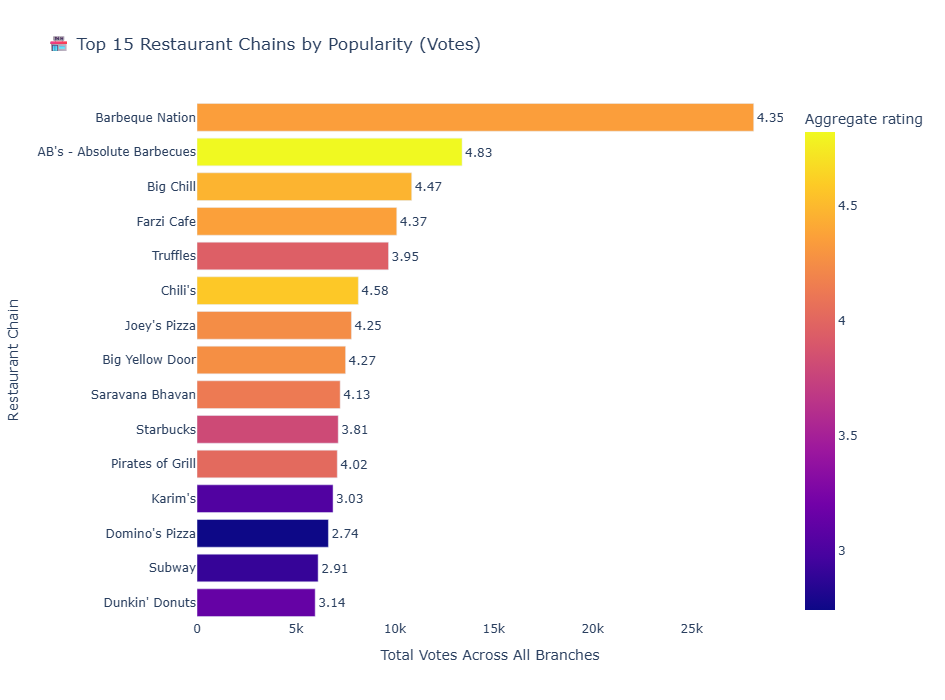

In [3]:
# 📦 Import Libraries
import pandas as pd
import plotly.express as px

# 📥 Load Dataset
df = pd.read_csv(r"C:\Users\acer\Downloads\Data Analysis Internship__Dataset__Cognifyz Technologies.csv") 

# 🔍 Step 1: Identify Restaurant Chains
chain_counts = df['Restaurant Name'].value_counts().reset_index()
chain_counts.columns = ['Restaurant Name', 'Branch Count']

# 🏪 Step 2: Filter chains with >1 branch
restaurant_chains = chain_counts[chain_counts['Branch Count'] > 1]

# 🔄 Step 3: Merge with original data
chain_data = pd.merge(restaurant_chains, df, on='Restaurant Name')

# 📊 Step 4: Group by chain for summary
chain_summary = chain_data.groupby('Restaurant Name').agg({
    'Branch Count': 'first',
    'Aggregate rating': 'mean',
    'Votes': 'sum'
}).reset_index()

chain_summary = chain_summary.sort_values(by='Votes', ascending=False)

# 🏆 Step 5: Top 15 Popular Chains
top_chains = chain_summary.head(15)

# 🎨 Step 6: Plot Popular Chains
fig = px.bar(
    top_chains,
    x='Votes',
    y='Restaurant Name',
    orientation='h',
    color='Aggregate rating',
    text='Aggregate rating',
    color_continuous_scale='Plasma',
    title='🏪 Top 15 Restaurant Chains by Popularity (Votes)'
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(
    xaxis_title='Total Votes Across All Branches',
    yaxis_title='Restaurant Chain',
    yaxis=dict(categoryorder='total ascending'),
    plot_bgcolor='white',
    height=700
)

fig.show()
